In [1]:
import warnings
# Suppress UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
# Suppress FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

from utils.utils import load_data,split_data,load_model,evaluate_model,plot_metrics

2025-05-01 17:46:24.024387: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-01 17:46:25.468629: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2025-05-01 17:46:29 | INFO     | DF | Running on torch 2.3.0+cu121
2025-05-01 17:46:29 | INFO     | DF | Running on host Sourav
2025-05-01 17:46:29 | INFO     | DF | Loading model settings of DeepFilterNet3
2025-05-01 17:46:29 | INFO     | DF | Using DeepFilterNet3 model at /home/sourav/.cache/DeepFilterNet/DeepFilterNet3
2025-05-01 17:46:30 | INFO     | DF | Initializing model `deepfilternet3`


fatal: not a git repository (or any of the parent directories): .git


2025-05-01 17:46:30 | INFO     | DF | Found checkpoint /home/sourav/.cache/DeepFilterNet/DeepFilterNet3/checkpoints/model_120.ckpt.best with epoch 120
2025-05-01 17:46:30 | INFO     | DF | Running on device cuda:0
2025-05-01 17:46:30 | INFO     | DF | Model loaded


In [2]:
model_name = 'CNN' # Choose between 'CNN', 'InceptionV3', 'MobileNetV2', 'ResNet50', 'VGG16', 'Xception'
train_data_directory = r'Commonvoice/mfcc/mfcc_images'
test_data_directory = r'test_audio'

model, image_size = load_model(model_name=model_name)
print(f"Model {model_name} loaded")

2025-05-01 17:46:35.786724: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 17:46:35.797845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 17:46:35.797941: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 17:46:35.800221: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-01 17:46:35.800383: I external/local_xla/xla/stream_executor

Model CNN loaded


Found 70000 files belonging to 2 classes.
Data loaded from Commonvoice/mfcc/mfcc_images with image size (256, 256)
Data split into train, validation, and test sets


I0000 00:00:1746101920.151485  170334 service.cc:145] XLA service 0x7f80301046a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746101920.151549  170334 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2025-05-01 17:48:40.202618: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-01 17:48:40.262179: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8902
I0000 00:00:1746101923.629818  170334 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model precision: 94.79%
Model recall: 93.29%
Model accuracy: 94.11%


2025-05-01 17:49:11.215120: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


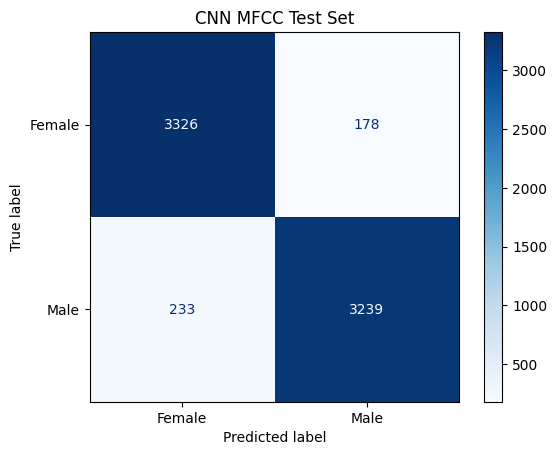

In [ ]:
data = load_data(data_dir=train_data_directory, batch_size=32, image_size=image_size)
data = data.map(lambda x,y: (x/255, y))
print(f"Data loaded from {train_data_directory} with image size {image_size}")
data = split_data(data)
print(f"Data split into train, validation, and test sets")

plot_metrics(model_title=model_name, model=model, data=data['test'], image_size=image_size)


2025-05-01 17:50:48 | WARNING  | DF | Audio sampling rate does not match model sampling rate (44100, 48000). Resampling...


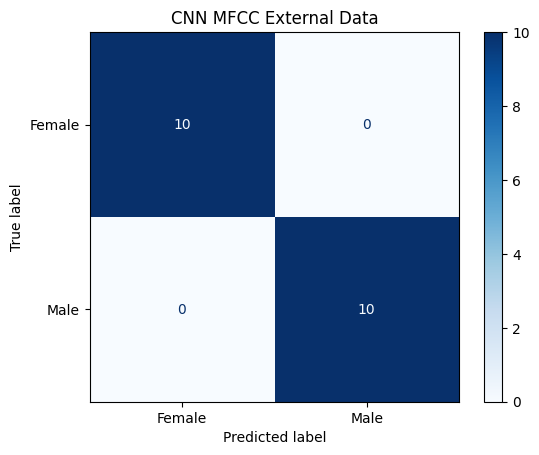

Model accuracy on new data: 100.00%
Average prediction time: 0.0853 seconds
Total files processed: 20
Model CNN evaluated on test dataset test_audio


In [4]:
evaluate_model(model_name=model_name, model=model, test_data_directory=test_data_directory, image_size=image_size)
print(f"Model {model_name} evaluated on test dataset {test_data_directory}")